In [168]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import seaborn as sns
import matplotlib.pyplot as plt


In [169]:
df = pd.read_csv("/content/drive/MyDrive/datasetindia_house_dataset.csv")

In [170]:
df.isna().sum()

,0
house_type,0
locality,0
city,0
area,0
beds,0
bathrooms,0
balconies,0
furnishing,0
area_rate,0
rent,0


In [171]:
df.head()

,house_type,locality,city,area,beds,bathrooms,balconies,furnishing,area_rate,rent
0,"2 BHK Flat for Rent in Oberoi Woods, Goregaon ...",Goregaon East,Mumbai,897.0,2,2,0,Semi-Furnished,134.0,120000.0
1,"1 BHK Flat for Rent in Sapphire Lakeside, Powa...",Powai,Mumbai,490.0,1,1,0,Semi-Furnished,82.0,40000.0
2,1 BHK House for Rent in Mundhwa Pune,Mundhwa,Pune,550.0,1,1,0,Unfurnished,22.0,12000.0
3,"2 BHK Flat for Rent in Hingna, Nagpur",Hingna,Nagpur,1000.0,2,2,0,Unfurnished,8.0,8000.0
4,1 BHK Flat for Rent in Unique Star Harsh Vihar...,Mira Road,Mumbai,595.0,1,1,0,Unfurnished,25.0,15000.0


In [172]:
df.tail()

,house_type,locality,city,area,beds,bathrooms,balconies,furnishing,area_rate,rent
7686,"3 BHK Flat for Rent in Saket, New Delhi",Saket,New Delhi,1750.0,3,3,0,Furnished,27.0,47000.0
7687,"2 BHK Flat for Rent in Phase 7 JP Nagar, Banga...",Phase 7 JP Nagar,Bangalore,1050.0,2,2,2,Semi-Furnished,27.0,28000.0
7688,"2 BHK Flat for Rent in Malpani Vivanta, Balewa...",Balewadi,Pune,734.0,2,2,2,Unfurnished,48.0,35000.0
7689,"1 BHK Flat for Rent in Shalimar bagh, New Delhi",Shalimar bagh,New Delhi,400.0,1,1,0,Semi-Furnished,38.0,15000.0
7690,"2 BHK Flat for Rent in Govindpura, Dooravani N...",Govindpura,Bangalore,450.0,2,1,0,Unfurnished,22.0,10000.0


In [173]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7691 entries, 0 to 7690
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   house_type  7691 non-null   object 
 1   locality    7691 non-null   object 
 2   city        7691 non-null   object 
 3   area        7691 non-null   float64
 4   beds        7691 non-null   int64  
 5   bathrooms   7691 non-null   int64  
 6   balconies   7691 non-null   int64  
 7   furnishing  7691 non-null   object 
 8   area_rate   7691 non-null   float64
 9   rent        7691 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 601.0+ KB


In [174]:
df.corr(numeric_only=True)['rent']

,rent
area,0.433513
beds,0.473695
bathrooms,0.532681
balconies,0.179181
area_rate,0.507104
rent,1.000000


In [175]:
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)

print("\nMissing values:")
print(df.isnull().sum())

df = df.dropna().reset_index(drop=True)

df = df.drop('area_rate', axis=1)

df['bhk'] = df['house_type'].str.extract(r'(\d+)').astype(int)

df = df.drop('house_type', axis=1)

df['locality'] = df['locality'].str.strip()
df['city'] = df['city'].str.strip()
df['furnishing'] = df['furnishing'].str.strip()

print(df.dtypes)

print("\nFinal shape:", df.shape)

print("\nFinal columns:")
print(df.columns)

print("\nFinal dataset:")
print(df.head())

Duplicate rows: 0

Missing values:
house_type    0
locality      0
city          0
area          0
beds          0
bathrooms     0
balconies     0
furnishing    0
area_rate     0
rent          0
dtype: int64
locality       object
city           object
area          float64
beds            int64
bathrooms       int64
balconies       int64
furnishing     object
rent          float64
bhk             int64
dtype: object

Final shape: (7691, 9)

Final columns:
Index(['locality', 'city', 'area', 'beds', 'bathrooms', 'balconies',
       'furnishing', 'rent', 'bhk'],
      dtype='object')

Final dataset:
        locality    city    area  beds  bathrooms  balconies      furnishing  \
0  Goregaon East  Mumbai   897.0     2          2          0  Semi-Furnished   
1          Powai  Mumbai   490.0     1          1          0  Semi-Furnished   
2        Mundhwa    Pune   550.0     1          1          0     Unfurnished   
3         Hingna  Nagpur  1000.0     2          2          0     Unfurnished

In [176]:
df = df.drop('bhk', axis=1)

print(df.shape)
print(df.columns)
print(df.head())

(7691, 8)
Index(['locality', 'city', 'area', 'beds', 'bathrooms', 'balconies',
       'furnishing', 'rent'],
      dtype='object')
        locality    city    area  beds  bathrooms  balconies      furnishing  \
0  Goregaon East  Mumbai   897.0     2          2          0  Semi-Furnished   
1          Powai  Mumbai   490.0     1          1          0  Semi-Furnished   
2        Mundhwa    Pune   550.0     1          1          0     Unfurnished   
3         Hingna  Nagpur  1000.0     2          2          0     Unfurnished   
4      Mira Road  Mumbai   595.0     1          1          0     Unfurnished   

       rent  
0  120000.0  
1   40000.0  
2   12000.0  
3    8000.0  
4   15000.0  


In [177]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7691 entries, 0 to 7690
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   locality    7691 non-null   object 
 1   city        7691 non-null   object 
 2   area        7691 non-null   float64
 3   beds        7691 non-null   int64  
 4   bathrooms   7691 non-null   int64  
 5   balconies   7691 non-null   int64  
 6   furnishing  7691 non-null   object 
 7   rent        7691 non-null   float64
dtypes: float64(2), int64(3), object(3)
memory usage: 480.8+ KB


In [178]:
df.describe()

,area,beds,bathrooms,balconies,rent
count,7691.000000,7691.000000,7691.000000,7691.000000,7.691000e+03
mean,1106.354180,2.208685,2.137043,0.817319,5.479508e+04
std,1197.426843,0.993481,1.027677,1.243361,9.742006e+04
min,2.000000,1.000000,0.000000,0.000000,1.000000e+03
25%,600.000000,1.000000,1.000000,0.000000,1.500000e+04
50%,900.000000,2.000000,2.000000,0.000000,2.800000e+04
75%,1300.000000,3.000000,3.000000,2.000000,5.700000e+04
max,70000.000000,10.000000,10.000000,10.000000,2.700000e+06


In [179]:
df[['beds', 'rent']].head(10)

,beds,rent
0,2,120000.0
1,1,40000.0
2,1,12000.0
3,2,8000.0
4,1,15000.0
5,1,16000.0
6,3,60000.0
7,3,200000.0
8,1,11000.0
9,1,24000.0


In [180]:
print(df.columns)

Index(['locality', 'city', 'area', 'beds', 'bathrooms', 'balconies',
       'furnishing', 'rent'],
      dtype='object')


In [181]:
df = df.drop_duplicates().reset_index(drop=True)
print("Remaining duplicates:", df.duplicated().sum())

Remaining duplicates: 0


In [182]:
print(df[df['area'] <= 0])
print(df[df['beds'] <= 0])
print(df[df['bathrooms'] <= 0])
print(df[df['balconies'] < 0])
print(df[df['rent'] <= 0])

Empty DataFrame
Columns: [locality, city, area, beds, bathrooms, balconies, furnishing, rent]
Index: []
Empty DataFrame
Columns: [locality, city, area, beds, bathrooms, balconies, furnishing, rent]
Index: []
                       locality       city    area  beds  bathrooms  \
136                     Chembur     Mumbai   300.0     1          0   
746       Lakkasandra Extension  Bangalore  5000.0    10          0   
3387                     Wadala     Mumbai   100.0     1          0   
3526                    Kalkaji  New Delhi   110.0     1          0   
4294               Andheri East     Mumbai  1010.0     3          0   
6621                   Nagavara  Bangalore   500.0     1          0   
7183  Greater Kailash Enclave 1  New Delhi  4050.0    10          0   

      balconies   furnishing      rent  
136           0  Unfurnished    5000.0  
746           4    Furnished  180000.0  
3387          0  Unfurnished    5000.0  
3526          0    Furnished   12000.0  
4294          0  U

In [183]:
df = df[df['bathrooms'] > 0].reset_index(drop=True)
print("Rows after removing invalid values:", len(df))
print("Bathrooms <= 0:", (df['bathrooms'] <= 0).sum())

Rows after removing invalid values: 7675
Bathrooms <= 0: 0


In [184]:
print("Cities:")
print(df['city'].unique())

print("\nFurnishing:")
print(df['furnishing'].unique())

print("\nNumber of localities:")
print(df['locality'].nunique())

Cities:
['Mumbai' 'Pune' 'Nagpur' 'Bangalore' 'New Delhi']

Furnishing:
['Semi-Furnished' 'Unfurnished' 'Furnished']

Number of localities:
1983


In [185]:
df['locality'] = df['locality'].str.strip()
df['city'] = df['city'].str.strip()
df['furnishing'] = df['furnishing'].str.strip()

In [186]:
def check_outliers(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    print(f"\n{column}")
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Outlier Count:", len(outliers))


for column in ['area', 'beds', 'bathrooms', 'balconies', 'rent']:
    check_outliers(column)


area
Q1: 600.0
Q3: 1300.0
IQR: 700.0
Lower Bound: -450.0
Upper Bound: 2350.0
Outlier Count: 488

beds
Q1: 1.0
Q3: 3.0
IQR: 2.0
Lower Bound: -2.0
Upper Bound: 6.0
Outlier Count: 15

bathrooms
Q1: 1.0
Q3: 3.0
IQR: 2.0
Lower Bound: -2.0
Upper Bound: 6.0
Outlier Count: 19

balconies
Q1: 0.0
Q3: 2.0
IQR: 2.0
Lower Bound: -3.0
Upper Bound: 5.0
Outlier Count: 13

rent
Q1: 15000.0
Q3: 57000.0
IQR: 42000.0
Lower Bound: -48000.0
Upper Bound: 120000.0
Outlier Count: 708


In [187]:
df = df[df['area'] >= 100].reset_index(drop=True)
df.shape

(7604, 8)

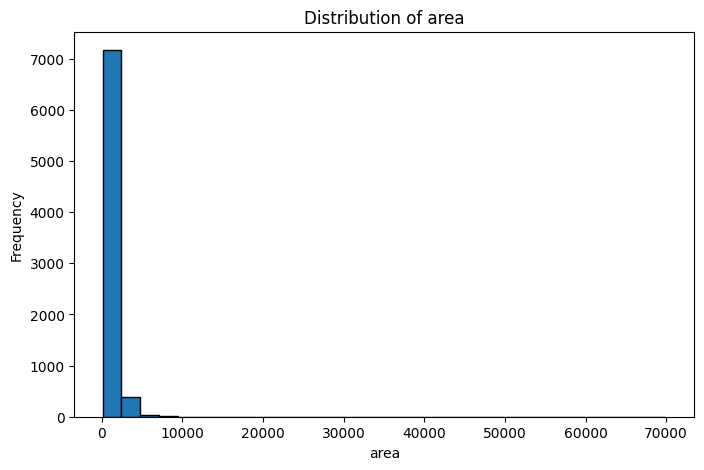

area         28.516102
beds          1.008910
bathrooms     1.238521
balconies     1.280551
rent          8.620777
dtype: float64


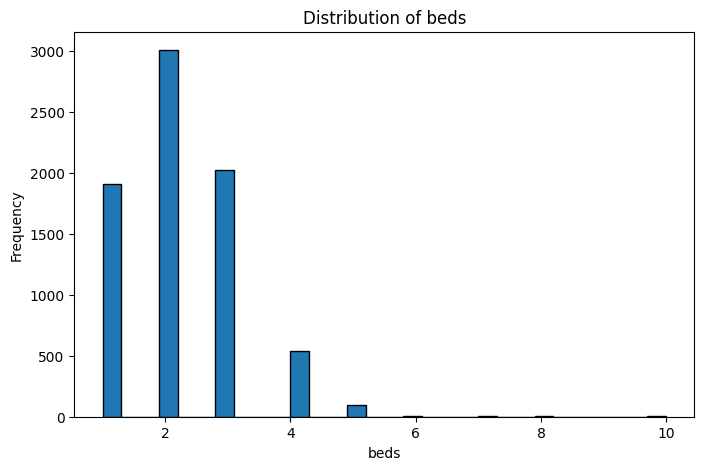

area         28.516102
beds          1.008910
bathrooms     1.238521
balconies     1.280551
rent          8.620777
dtype: float64


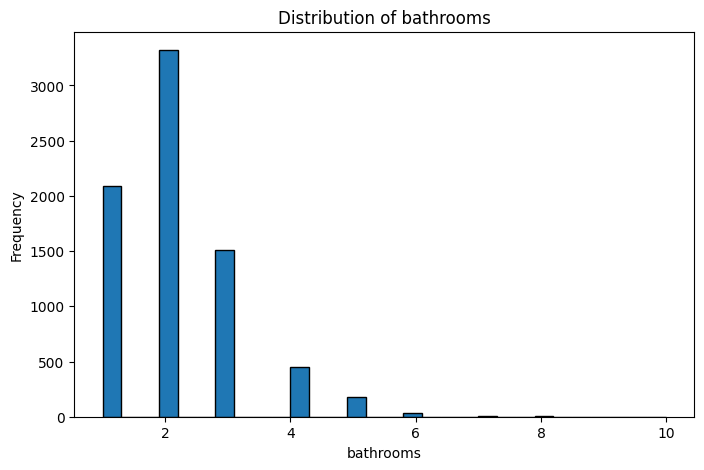

area         28.516102
beds          1.008910
bathrooms     1.238521
balconies     1.280551
rent          8.620777
dtype: float64


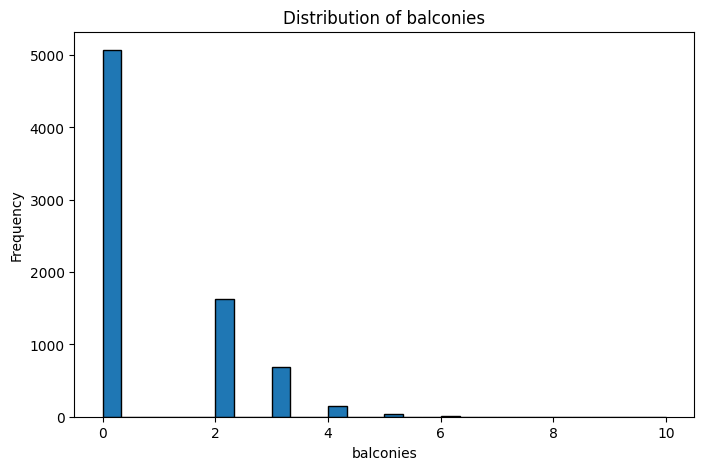

area         28.516102
beds          1.008910
bathrooms     1.238521
balconies     1.280551
rent          8.620777
dtype: float64


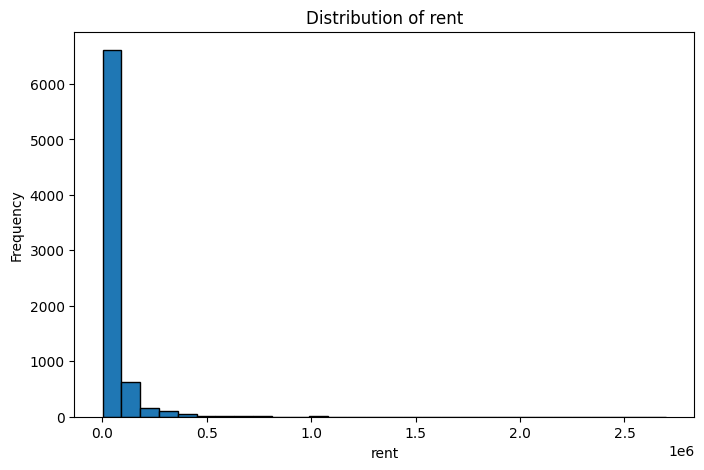

area         28.516102
beds          1.008910
bathrooms     1.238521
balconies     1.280551
rent          8.620777
dtype: float64


In [188]:
numerical_columns = [
    'area',
    'beds',
    'bathrooms',
    'balconies',
    'rent'
]
categorical_columns = [
    'locality',
    'city',
    'furnishing'
]
for column in numerical_columns:
    plt.figure(figsize=(8, 5))

    plt.hist(
        df[column],
        bins=30,
        edgecolor='black'
    )

    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {column}')

    plt.show()
    print(df[numerical_columns].skew())

In [189]:
df['area_log'] = np.log1p(df['area'])
df['rent_log'] = np.log1p(df['rent'])
print("Original skewness:")
print(df[['area', 'rent']].skew())

print("\nLog transformed skewness:")
print(df[['area_log', 'rent_log']].skew())

Original skewness:
area    28.516102
rent     8.620777
dtype: float64

Log transformed skewness:
area_log    0.106661
rent_log    0.493355
dtype: float64


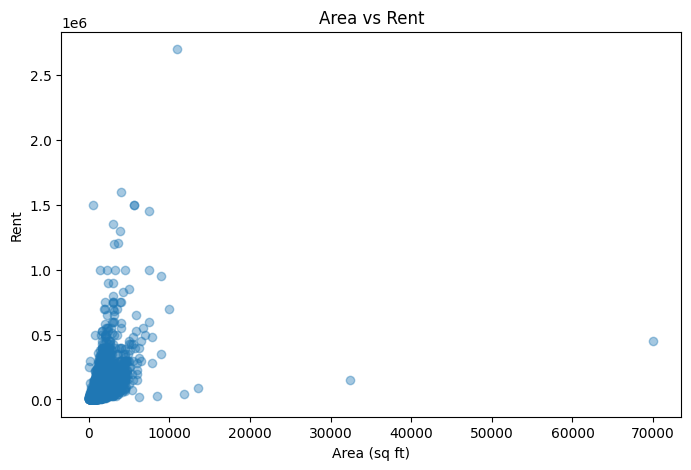

In [190]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['area'],
    df['rent'],
    alpha=0.4
)

plt.xlabel('Area (sq ft)')
plt.ylabel('Rent')
plt.title('Area vs Rent')

plt.show()

In [191]:


corr = df[numerical_columns].corr()

print(corr)
print(corr['rent'].sort_values(ascending=False))

               area      beds  bathrooms  balconies      rent
area       1.000000  0.514822   0.537323   0.294023  0.431205
beds       0.514822  1.000000   0.862939   0.420333  0.469308
bathrooms  0.537323  0.862939   1.000000   0.442824  0.537811
balconies  0.294023  0.420333   0.442824   1.000000  0.179229
rent       0.431205  0.469308   0.537811   0.179229  1.000000
rent         1.000000
bathrooms    0.537811
beds         0.469308
area         0.431205
balconies    0.179229
Name: rent, dtype: float64


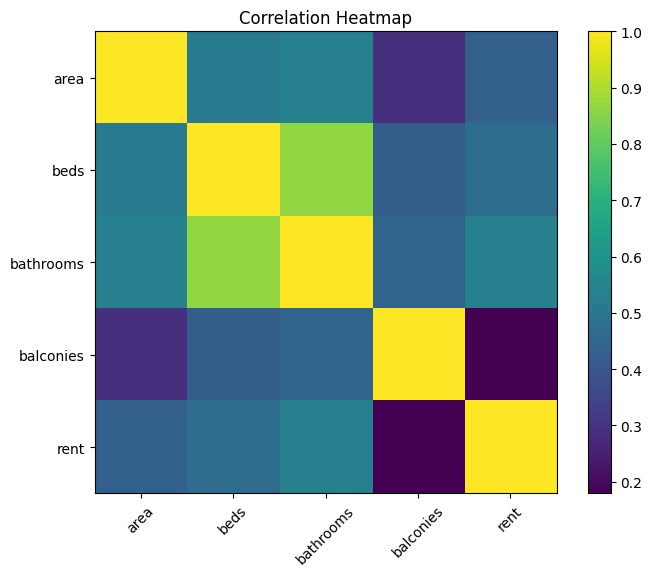

In [192]:
plt.figure(figsize=(8, 6))

plt.imshow(
    corr,
    interpolation='nearest'
)

plt.colorbar()

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title('Correlation Heatmap')

plt.show()

In [193]:
log_corr = df[['area_log', 'beds', 'bathrooms', 'balconies', 'rent_log']].corr()

print(log_corr)
print(log_corr['rent_log'].sort_values(ascending=False))

           area_log      beds  bathrooms  balconies  rent_log
area_log   1.000000  0.793955   0.774422   0.429679  0.661992
beds       0.793955  1.000000   0.862939   0.420333  0.660366
bathrooms  0.774422  0.862939   1.000000   0.442824  0.718513
balconies  0.429679  0.420333   0.442824   1.000000  0.315649
rent_log   0.661992  0.660366   0.718513   0.315649  1.000000
rent_log     1.000000
bathrooms    0.718513
area_log     0.661992
beds         0.660366
balconies    0.315649
Name: rent_log, dtype: float64


In [194]:

df = df.drop(
    columns=['rent_per_sqft_check', 'area_per_bed_check'],
    errors='ignore'
)

print(df.shape)
print(df.columns)

(7604, 10)
Index(['locality', 'city', 'area', 'beds', 'bathrooms', 'balconies',
       'furnishing', 'rent', 'area_log', 'rent_log'],
      dtype='object')


In [195]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

X = df[
    [
        'locality',
        'city',
        'area_log',
        'beds',
        'bathrooms',
        'balconies',
        'furnishing'
    ]
]

y = df['rent_log']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
categorical_features = [
    'locality',
    'city',
    'furnishing'
]
preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ],
    remainder='passthrough'
)
model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)
model.fit(X_train, y_train)

y_pred_log = model.predict(X_test)

y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(y_test)

r2 = r2_score(y_actual, y_pred)

mae = mean_absolute_error(y_actual, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_actual, y_pred)
)

print("R²   :", r2)
print("MAE  :", mae)
print("RMSE :", rmse)

R²   : 0.6410550996996939
MAE  : 17661.92089367579
RMSE : 49426.25183995107


In [196]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


X = df[
    [
        'locality',
        'city',
        'area_log',
        'beds',
        'bathrooms',
        'balconies',
        'furnishing'
    ]
]

y = df['rent_log']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
categorical_features = [
    'locality',
    'city',
    'furnishing'
]
preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ],
    remainder='passthrough'
)
tree_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'model',
            DecisionTreeRegressor(
                random_state=42
            )
        )
    ]
)
tree_model.fit(X_train, y_train)

y_pred_log = tree_model.predict(X_test)

y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(y_test)

r2 = r2_score(y_actual, y_pred)

mae = mean_absolute_error(
    y_actual,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_actual,
        y_pred
    )
)


print("Decision Tree Regressor")

print("R²   :", r2)
print("MAE  :", mae)
print("RMSE :", rmse)

Decision Tree Regressor
R²   : 0.5922904703730858
MAE  : 21943.582255540805
RMSE : 52676.779450852955


In [197]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)
import numpy as np
import pandas as pd

depths = [3, 5, 7, 10, 15, 20, None]

results = []

for depth in depths:

    tree = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            (
                'model',
                DecisionTreeRegressor(
                    max_depth=depth,
                    random_state=42
                )
            )
        ]
    )


    tree.fit(X_train, y_train)

    train_pred_log = tree.predict(X_train)


    test_pred_log = tree.predict(X_test)

    train_pred = np.expm1(train_pred_log)
    test_pred = np.expm1(test_pred_log)

    train_actual = np.expm1(y_train)
    test_actual = np.expm1(y_test)

    train_r2 = r2_score(train_actual, train_pred)
    test_r2 = r2_score(test_actual, test_pred)

    train_mae = mean_absolute_error(
        train_actual,
        train_pred
    )

    test_mae = mean_absolute_error(
        test_actual,
        test_pred
    )

    train_rmse = np.sqrt(
        mean_squared_error(
            train_actual,
            train_pred
        )
    )

    test_rmse = np.sqrt(
        mean_squared_error(
            test_actual,
            test_pred
        )
    )

    results.append({
        'max_depth': depth,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse
    })

results_df = pd.DataFrame(results)

print(results_df)

   max_depth  train_r2   test_r2     train_mae      test_mae    train_rmse  \
0        3.0  0.396349  0.525715  26005.601920  23581.282047  78308.831321   
1        5.0  0.675799  0.598099  21101.040519  20963.593202  57388.518195   
2        7.0  0.841910  0.591888  17775.062919  20580.523405  40074.648071   
3       10.0  0.907899  0.570825  14537.600552  20279.239343  30587.983331   
4       15.0  0.957084  0.506970  10363.790716  20690.037648  20879.819814   
5       20.0  0.977721  0.555401   7403.332390  20382.025585  15044.150689   
6        NaN  0.999646  0.592290    194.899099  21943.582256   1896.848936   

      test_rmse  
0  56815.075983  
1  52300.206184  
2  52702.748039  
3  54045.696510  
4  57926.947127  
5  55008.263117  
6  52676.779451  


In [198]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline

final_tree = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'model',
            DecisionTreeRegressor(
                max_depth=5,
                min_samples_split=2,
                min_samples_leaf=20,
                random_state=42
            )
        )
    ]
)
final_tree.fit(X_train, y_train)

y_pred_log = final_tree.predict(X_test)

y_pred = np.expm1(y_pred_log)
y_actual = np.expm1(y_test)
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

tree_test_r2 = r2_score(
    y_actual,
    y_pred
)

tree_test_mae = mean_absolute_error(
    y_actual,
    y_pred
)

tree_test_rmse = np.sqrt(
    mean_squared_error(
        y_actual,
        y_pred
    )
)

print("Final Tuned Decision Tree")
print("R²   :", tree_test_r2)
print("MAE  :", tree_test_mae)
print("RMSE :", tree_test_rmse)

Final Tuned Decision Tree
R²   : 0.6969315655320025
MAE  : 20543.049828408068
RMSE : 45416.54959517563



FINAL MODEL COMPARISON
                Model     R2      MAE     RMSE
Log Linear Regression 0.6411 17661.92 49426.25
  Tuned Decision Tree 0.6969 20543.05 45416.55
        Random Forest 0.8019 16828.16 38517.80
              XGBoost 0.8242 15554.86 34587.99


,Model,R2,MAE,RMSE
0,Log Linear Regression,0.6411,"₹17,661.92","₹49,426.25"
1,Tuned Decision Tree,0.6969,"₹20,543.05","₹45,416.55"
2,Random Forest,0.8019,"₹16,828.16","₹38,517.80"
3,XGBoost,0.8242,"₹15,554.86","₹34,587.99"



MODELS BY R²
                Model     R2
              XGBoost 0.8242
        Random Forest 0.8019
  Tuned Decision Tree 0.6969
Log Linear Regression 0.6411

MODELS BY MAE
                Model      MAE
              XGBoost 15554.86
        Random Forest 16828.16
Log Linear Regression 17661.92
  Tuned Decision Tree 20543.05

MODELS BY RMSE
                Model     RMSE
              XGBoost 34587.99
        Random Forest 38517.80
  Tuned Decision Tree 45416.55
Log Linear Regression 49426.25

XGBOOST vs LOG LINEAR REGRESSION
R² improvement : 28.56%
MAE reduction  : 11.93%
RMSE reduction : 30.02%


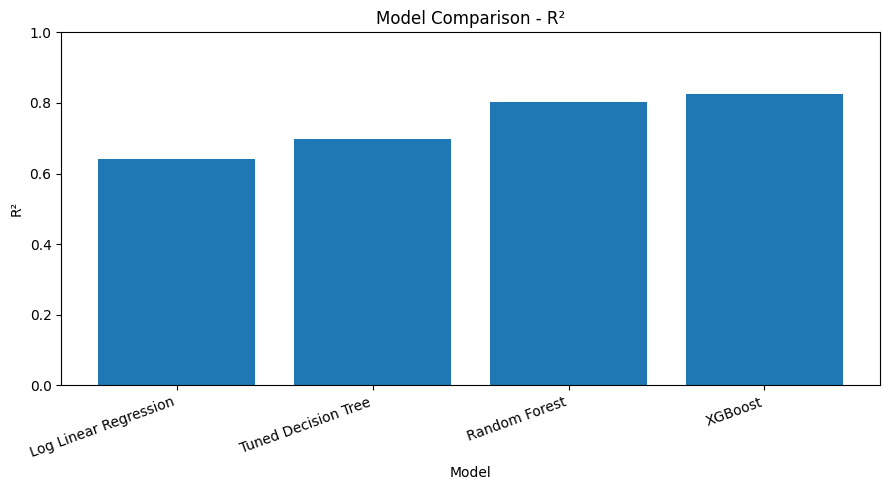

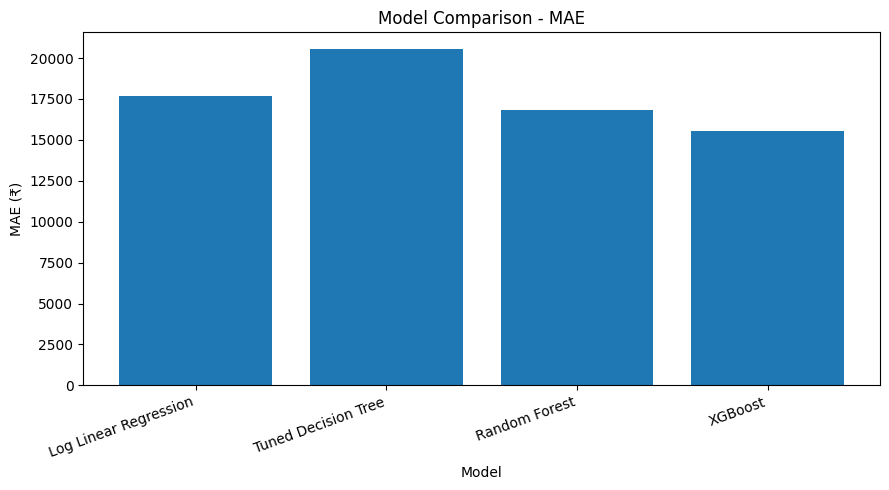

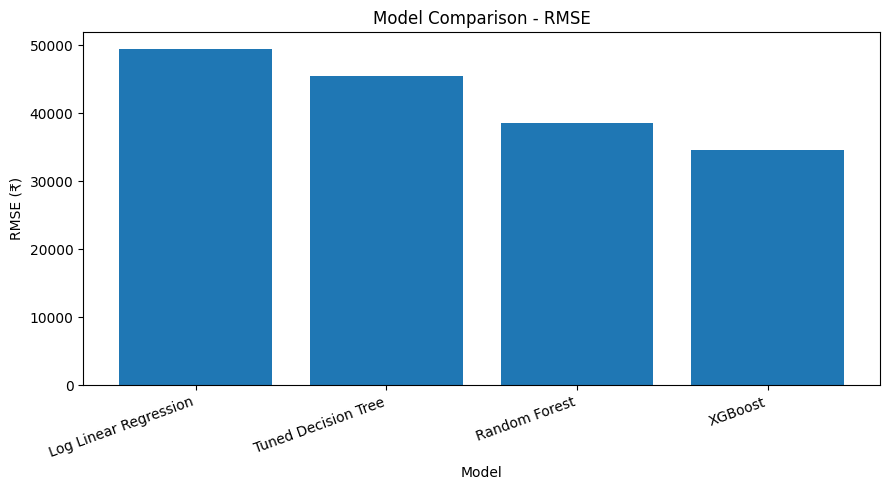


FINAL REPORT TABLE
                Model     R2        MAE       RMSE
Log Linear Regression 0.6411 ₹17,661.92 ₹49,426.25
  Tuned Decision Tree 0.6969 ₹20,543.05 ₹45,416.55
        Random Forest 0.8019 ₹16,828.16 ₹38,517.80
              XGBoost 0.8242 ₹15,554.86 ₹34,587.99


In [199]:


model_results = pd.DataFrame({

    'Model': [
        'Log Linear Regression',
        'Tuned Decision Tree',
        'Random Forest',
        'XGBoost'
    ],

    'R2': [
        0.6410550997,
        0.6969315655,
        0.8019090826,
        0.8242225555
    ],

    'MAE': [
        17661.9208937,
        20543.0498284,
        16828.1565657,
        15554.8646264
    ],

    'RMSE': [
        49426.25184,
        45416.54960,
        38517.80377,
        34587.99258
    ]
})



comparison = model_results.copy()

comparison['R2'] = comparison['R2'].round(4)
comparison['MAE'] = comparison['MAE'].round(2)
comparison['RMSE'] = comparison['RMSE'].round(2)

print("\nFINAL MODEL COMPARISON")
print("======================")

print(
    comparison.to_string(index=False)
)



display(
    comparison.style.format({
        'R2': '{:.4f}',
        'MAE': '₹{:,.2f}',
        'RMSE': '₹{:,.2f}'
    })
)


r2_ranking = comparison.sort_values(
    'R2',
    ascending=False
)

mae_ranking = comparison.sort_values(
    'MAE',
    ascending=True
)

rmse_ranking = comparison.sort_values(
    'RMSE',
    ascending=True
)


print("\nMODELS BY R²")
print("============")

print(
    r2_ranking[
        ['Model', 'R2']
    ].to_string(index=False)
)


print("\nMODELS BY MAE")
print("=============")

print(
    mae_ranking[
        ['Model', 'MAE']
    ].to_string(index=False)
)


print("\nMODELS BY RMSE")
print("==============")

print(
    rmse_ranking[
        ['Model', 'RMSE']
    ].to_string(index=False)
)


linear_r2 = comparison.loc[
    comparison['Model'] == 'Log Linear Regression',
    'R2'
].iloc[0]

linear_mae = comparison.loc[
    comparison['Model'] == 'Log Linear Regression',
    'MAE'
].iloc[0]

linear_rmse = comparison.loc[
    comparison['Model'] == 'Log Linear Regression',
    'RMSE'
].iloc[0]


xgb_r2 = comparison.loc[
    comparison['Model'] == 'XGBoost',
    'R2'
].iloc[0]

xgb_mae = comparison.loc[
    comparison['Model'] == 'XGBoost',
    'MAE'
].iloc[0]

xgb_rmse = comparison.loc[
    comparison['Model'] == 'XGBoost',
    'RMSE'
].iloc[0]


r2_improvement = (
    (xgb_r2 - linear_r2)
    / linear_r2
) * 100

mae_reduction = (
    (linear_mae - xgb_mae)
    / linear_mae
) * 100

rmse_reduction = (
    (linear_rmse - xgb_rmse)
    / linear_rmse
) * 100


print("\nXGBOOST vs LOG LINEAR REGRESSION")
print("================================")

print(
    f"R² improvement : {r2_improvement:.2f}%"
)

print(
    f"MAE reduction  : {mae_reduction:.2f}%"
)

print(
    f"RMSE reduction : {rmse_reduction:.2f}%"
)



plt.figure(figsize=(9, 5))

plt.bar(
    comparison['Model'],
    comparison['R2']
)

plt.xlabel('Model')
plt.ylabel('R²')
plt.title('Model Comparison - R²')

plt.xticks(
    rotation=20,
    ha='right'
)

plt.ylim(
    0,
    1
)

plt.tight_layout()
plt.show()


plt.figure(figsize=(9, 5))

plt.bar(
    comparison['Model'],
    comparison['MAE']
)

plt.xlabel('Model')
plt.ylabel('MAE (₹)')
plt.title('Model Comparison - MAE')

plt.xticks(
    rotation=20,
    ha='right'
)

plt.tight_layout()
plt.show()



plt.figure(figsize=(9, 5))

plt.bar(
    comparison['Model'],
    comparison['RMSE']
)

plt.xlabel('Model')
plt.ylabel('RMSE (₹)')
plt.title('Model Comparison - RMSE')

plt.xticks(
    rotation=20,
    ha='right'
)

plt.tight_layout()
plt.show()



final_table = comparison.copy()

final_table['MAE'] = final_table['MAE'].apply(
    lambda x: f"₹{x:,.2f}"
)

final_table['RMSE'] = final_table['RMSE'].apply(
    lambda x: f"₹{x:,.2f}"
)

final_table['R2'] = final_table['R2'].apply(
    lambda x: f"{x:.4f}"
)


print("\nFINAL REPORT TABLE")
print("==================")

print(
    final_table.to_string(index=False)
)

In [200]:

model_comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest',
        'XGBoost'
    ],

    'R2': [
        0.6410550997,
        0.6969315655,
        0.8019090826,
        0.8242225555
    ],

    'MAE': [
        17661.9208937,
        20543.0498284,
        16828.1565657,
        15554.8646264
    ],

    'RMSE': [
        49426.25184,
        45416.54960,
        38517.80377,
        34587.99258
    ]
})
print(model_comparison.to_string(index=False))

            Model       R2          MAE        RMSE
Linear Regression 0.641055 17661.920894 49426.25184
    Decision Tree 0.696932 20543.049828 45416.54960
    Random Forest 0.801909 16828.156566 38517.80377
          XGBoost 0.824223 15554.864626 34587.99258


In [201]:
df[numerical_columns].skew()

,0
area,28.516102
beds,1.008910
bathrooms,1.238521
balconies,1.280551
rent,8.620777


Number of transformed features: 1759
                     Feature  Importance
        remainder__bathrooms    0.183311
            cat__city_Mumbai    0.167418
            cat__city_Nagpur    0.078150
             remainder__beds    0.024939
         remainder__area_log    0.023794
   cat__furnishing_Furnished    0.017649
  cat__locality_Naigaon East    0.014245
         cat__locality_Worli    0.012509
    cat__locality_Virar West    0.011686
cat__locality_Defence Colony    0.010385
     cat__locality_Mira Road    0.009605
       cat__locality_Chembur    0.008764
     cat__locality_Najafgarh    0.007157
 cat__furnishing_Unfurnished    0.007157
   cat__locality_Nala Sopara    0.006988
    cat__locality_Prabhadevi    0.006895
         cat__locality_Virar    0.006483
   cat__locality_Bandra West    0.005661
         cat__locality_Parel    0.004960
       cat__locality_Wagholi    0.004744


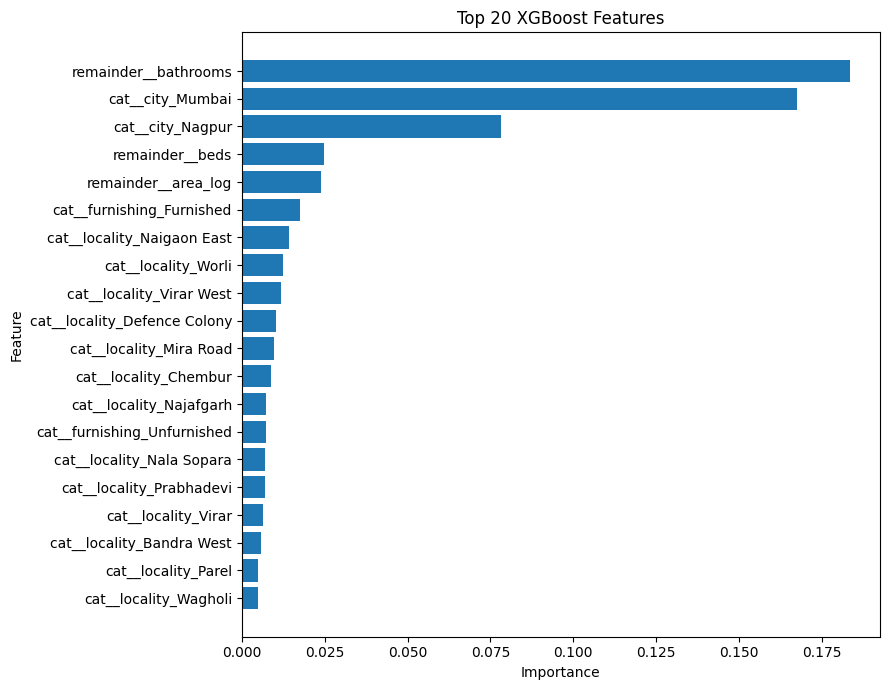

In [202]:

fitted_preprocessor = (
    best_xgb
    .named_steps['preprocessor']
)
feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)

print("Number of transformed features:", len(feature_names))
xgb_model = (
    best_xgb
    .named_steps['model']
)

importance = xgb_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_importance = (
    feature_importance
    .sort_values(
        'Importance',
        ascending=False
    )
)

print(
    feature_importance.head(20)
    .to_string(index=False)
)
top_features = (
    feature_importance
    .head(20)
    .sort_values(
        'Importance'
    )
)

plt.figure(figsize=(9, 7))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 20 XGBoost Features')

plt.tight_layout()
plt.show()

In [203]:
df['area_log'].skew()

np.float64(0.1066607882633589)

In [204]:
#Limitations
#1. Higher varieties of values in localities columns that can make more computation cost bcz if i use onehotcoding it will create so many features.
#2. Extreme vaalues in area columns and also lower values like 2,3,5 sqft that is not possible in a bhk flat/house.
#3. area is heavily right skewed that can easily downgrade the performance of models
#future improvements
#1. Optimize the xgboost model performance metrics.
#2. Prepare data more consistent before training and testing it on any model.
#3. More real world features can add value during modell training. ex- property_age,totaal_floors,dist from metrostations,parking etc.

In [205]:
# .What is the target variable?
# 2.Is this classification or regression?
# 3.How many features were used?
# 4.Were there missing values?
# 5.How were missing values handled?
# 6.Were duplicate records found?
# 7.Which features required encoding?
# 8.Was feature scaling performed?
# 9.What was the baseline model?
# 10.Which models were compared?
# 11.What are the MAE, RMSE and R² values?
# 12.What feature engineering was performed?
# 13.Which features were most important for the selected model?
# 14.What limitations does the model have?
# # 15.How could the project be improved further?